In [40]:
# importing required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sci
from sklearn import linear_model
from sklearn.linear_model import LinearRegression

In [3]:
# reading the given dataset into a pandas dataframe
cars_data = pd.read_csv("CarPrice_Assignment.csv")

In [4]:
# checking the basic information of the df
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [4]:
#splitting the car brand/company name from carname field

carnames = cars_data['CarName'].apply(lambda x: x.split()[0])       

carnames

0      alfa-romero
1      alfa-romero
2      alfa-romero
3             audi
4             audi
          ...     
200          volvo
201          volvo
202          volvo
203          volvo
204          volvo
Name: CarName, Length: 205, dtype: object

In [5]:
cars_data['car_company'] = cars_data['CarName'].apply(lambda x: x.split()[0])    

In [6]:
cars_data['car_company'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [7]:
# fixing car spellings
cars_data.loc[cars_data['car_company'] == "maxda", 'car_company'] = 'mazda'
cars_data.loc[cars_data['car_company'] == "Nissan", 'car_company'] = 'nissan'
cars_data.loc[cars_data['car_company'] == "porcshce", 'car_company'] = 'porsche'
cars_data.loc[cars_data['car_company'] == "toyouta", 'car_company'] = 'toyota'
cars_data.loc[(cars_data['car_company'] == "vw") | (cars_data['car_company'] == "vokswagen"), 'car_company'] = 'volkswagen'


### Data Prep


In [8]:
#checking the first 5 rows of the df
cars_data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,car_company
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [12]:
cars_data['cylindernumber'].unique()	

array(['4', '6', '5', '3', '12', '2', '8'], dtype=object)

In [10]:

def help_dict(x):
    return x.map({
    'one': '1',
    'two': '2',
    'three': '3',
    'four': '4',
    'five': '5',
    'six': '6',
    'seven': '7',
    'eight': '8',
    'nine': '9',
    'zero': '0',
    'twelve' : '12'    
})
cars_data['doornumber'] =cars_data[['doornumber']].apply(help_dict)
cars_data['cylindernumber'] =cars_data[['cylindernumber']].apply(help_dict)

In [32]:
# Drop not useful variables
#cars_data = cars_data.drop('CarName', axis=1)
cars_data = cars_data.drop('car_ID', axis=1)

In [20]:
cars_data['cylindernumber']=cars_data['cylindernumber'].astype(np.int64)

In [21]:
cars_data['doornumber']=cars_data['doornumber'].astype(np.int64)

In [ ]:
#dummy variables
cars_categorical = cars_data.select_dtypes(include=['object'])
cars_categorical.head()

In [23]:
cars_dummies = pd.get_dummies(cars_categorical, drop_first=True)
cars_dummies.head()

,fueltype_gas,aspiration_turbo,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginelocation_rear,enginetype_dohcv,...,car_company_nissan,car_company_peugeot,car_company_plymouth,car_company_porsche,car_company_renault,car_company_saab,car_company_subaru,car_company_toyota,car_company_volkswagen,car_company_volvo
0,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [25]:
# Drop categorical variable columns
cars_data = cars_data.drop(list(cars_categorical.columns), axis=1)

In [26]:
# Concatenate dummy variables with X
cars_data = pd.concat([cars_data, cars_dummies], axis=1)


In [33]:
cars_data.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,car_company_nissan,car_company_peugeot,car_company_plymouth,car_company_porsche,car_company_renault,car_company_saab,car_company_subaru,car_company_toyota,car_company_volkswagen,car_company_volvo
0,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,False,False,False,False
2,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,False,False,False,False,False,False,False,False,False,False
3,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,False,False,False,False,False,False,False,False,False,False
4,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,False,False,False,False,False,False,False,False,False,False


In [37]:
# All numeric (float and int) variables in the dataset
cars_numeric = cars_data.select_dtypes(include=['float64', 'int64'])
cars_numeric.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,3.40,8.0,115,5500,18,22,17450.0


In [38]:
cars_numeric.columns

Index(['symboling', 'doornumber', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'cylindernumber', 'enginesize', 'boreratio',
       'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg',
       'highwaympg', 'price'],
      dtype='object')

In [92]:
# Split the datafram into train and test sets
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(cars_data, train_size=0.8, test_size=0.2, random_state=100)

In [93]:
# Import the StandardScaler()
from sklearn.preprocessing import StandardScaler

# Create a scaling object
scaler = StandardScaler()

# Create a list of the variables that you need to scale
varlist = ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight','curbweight', 'enginesize', 'boreratio', 'stroke', 
           'compressionratio','horsepower', 'peakrpm', 'citympg', 'highwaympg', 'doornumber', 'cylindernumber', 'price']

# Scale these variables using 'fit_transform'
df_train[varlist] = scaler.fit_transform(df_train[varlist])

In [94]:
# Let's take a look at the train dataframe now
df_train.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,car_company_nissan,car_company_peugeot,car_company_plymouth,car_company_porsche,car_company_renault,car_company_saab,car_company_subaru,car_company_toyota,car_company_volkswagen,car_company_volvo
3,0.965645,0.873751,0.256524,0.290980,0.205880,0.286269,-0.343330,-0.339966,-0.372828,-0.419206,...,False,False,False,False,False,False,False,False,False,False
157,-0.692635,0.873751,-0.460676,-0.558965,-0.630100,-0.322919,-0.781780,-0.339966,-0.652371,-0.419206,...,False,False,False,False,False,False,False,True,False,False
81,1.794784,-1.144491,-0.355720,-0.006088,-0.165667,-1.703744,-0.360637,-0.339966,-0.042458,0.205437,...,False,False,False,False,False,False,False,False,False,False
32,0.136505,-1.144491,-0.810530,-1.904025,-0.815873,-0.404144,-1.304842,-0.339966,-1.135218,-1.512333,...,False,False,False,False,False,False,False,False,False,False
99,-0.692635,0.873751,-0.198286,0.026919,-0.258553,0.448719,-0.368329,-0.339966,-0.093284,0.127357,...,True,False,False,False,False,False,False,False,False,False


In [95]:
# Split the train dataset into X and y

y_train = df_train.pop('price')
X_train = df_train

In [96]:
# Instantiate
lm = LinearRegression()

# Fit a line
lm.fit(X_train, y_train)

LinearRegression()

In [97]:
# Print the coefficients and intercept
print(lm.coef_)
print(lm.intercept_)

[-5.87117847e-04  2.30467788e-02  2.45513528e-01 -1.14903792e-01
  1.24151509e-01 -1.51482254e-01  3.11772532e-01 -2.64355921e-01
  8.08633856e-01 -2.63751828e-01 -9.53959924e-02 -3.71815738e-01
  2.60293687e-02  1.57663275e-01  1.49078442e-01  1.11270451e-02
 -1.06222871e+13  2.91732131e-01 -5.91576424e-01 -6.12769070e-01
 -4.94998615e-01 -4.50493942e-01 -2.09920992e-02  4.92615058e-02
 -1.43696561e+13  6.60565072e-01  9.01582631e-01  2.84023201e-01
  1.43696561e+13  8.15740430e-02  1.03689266e+00  5.00261340e-02
 -3.81163240e-01 -1.06222871e+13 -2.69464227e-01 -1.50431628e-01
 -1.16433945e-01  1.18471575e+12 -4.15821723e-02  9.59825396e-01
  2.22576208e-01 -6.98025269e-01 -6.66885453e-01 -5.76656178e-01
 -4.19955527e-01 -1.84273006e-01 -2.07426479e-01 -8.48403316e+08
 -7.99854547e-01 -3.47580427e-01 -1.29920321e+00 -6.76655804e-01
  7.63719927e-01 -2.54167389e-01  5.52515829e-01 -1.43696561e+13
 -2.75714074e-01 -1.88512143e-01 -2.74646260e-02]
10622287101810.28


In [98]:
# Import RFE
from sklearn.feature_selection import RFE

# RFE with 15 features
rfe1 = RFE(LinearRegression(),n_features_to_select=15)

# Fit with 15 features
rfe1.fit(X_train, y_train)

# Print the boolean results
print(rfe1.support_)           
print(rfe1.ranking_)  

[False False False False False False  True False  True False False False
 False False False False False False False False False False False False
  True False False False False False  True False False False  True False
 False False False  True  True False False False False False False False
  True  True  True  True  True  True False  True  True False False]
[45 41 19 16 13 20  1 32  1 30 33 11 42 27 25 36 10 24 15 17 22 23 37 35
  1 28  6 29 12 34  1 38  8  9  1 21 26 39 44  1  1  7  2  4 14 31  3 40
  1  1  1  1  1  1 18  1  1  5 43]


In [103]:
# Import statsmodels
import statsmodels.api as sm  

# Subset the features selected by rfe1
col1 = X_train.columns[rfe1.support_]

# Subsetting training data for 15 selected columns
X_train_rfe1 = X_train[col1]

# Add a constant to the model
X_train_rfe1 = sm.add_constant(X_train_rfe1)
X_train_rfe1.head()
X_train_rfe1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164 entries, 3 to 8
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   const                   164 non-null    float64
 1   curbweight              164 non-null    float64
 2   enginesize              164 non-null    float64
 3   enginelocation_rear     164 non-null    bool   
 4   enginetype_rotor        164 non-null    bool   
 5   fuelsystem_mfi          164 non-null    bool   
 6   car_company_bmw         164 non-null    bool   
 7   car_company_buick       164 non-null    bool   
 8   car_company_mitsubishi  164 non-null    bool   
 9   car_company_nissan      164 non-null    bool   
 10  car_company_peugeot     164 non-null    bool   
 11  car_company_plymouth    164 non-null    bool   
 12  car_company_porsche     164 non-null    bool   
 13  car_company_renault     164 non-null    bool   
 14  car_company_subaru      164 non-null    bool   
 

In [104]:
# Fitting the model with 15 variables
model1 = sm.OLS(y_train, X_train_rfe1.astype(float)).fit()   
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     131.0
Date:                Sun, 25 Aug 2024   Prob (F-statistic):           2.35e-77
Time:                        16:57:36   Log-Likelihood:                -14.697
No. Observations:                 164   AIC:                             61.39
Df Residuals:                     148   BIC:                             111.0
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

In [100]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [107]:
X_train_rfe1.shape[1]

16

In [116]:
vif = pd.DataFrame()
vif['Features'] = X_train_rfe1.columns
vif['VIF'] = [variance_inflation_factor(X_train_rfe1.values.astype(float), i) for i in range(X_train_rfe1.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,curbweight,7.06
2,enginesize,6.79
0,const,2.46
12,car_company_porsche,2.09
3,enginelocation_rear,2.05
10,car_company_peugeot,1.49
7,car_company_buick,1.31
4,enginetype_rotor,1.24
15,car_company_toyota,1.16
9,car_company_nissan,1.15


In [127]:
# RFE with 10 features
from sklearn.feature_selection import RFE

# RFE with 10 features
rfe2 = RFE(LinearRegression(), n_features_to_select=10)

# Fit with 10 features
rfe2.fit(X_train, y_train)

RFE(estimator=LinearRegression(), n_features_to_select=10)

In [128]:
# Subset the features selected by rfe2
col2 = X_train.columns[rfe2.support_]

# Subsetting training data for 10 selected columns
X_train_rfe2 = X_train[col2]

# Add a constant to the model
X_train_rfe2 = sm.add_constant(X_train_rfe2)

# Fitting the model with 10 variables
model2 = sm.OLS(y_train, X_train_rfe2.astype(float)).fit()     
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     158.0
Date:                Sun, 25 Aug 2024   Prob (F-statistic):           2.55e-75
Time:                        17:19:01   Log-Likelihood:                -33.664
No. Observations:                 164   AIC:                             89.33
Df Residuals:                     153   BIC:                             123.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0952    

In [129]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train_rfe2.columns
vif['VIF'] = [variance_inflation_factor(X_train_rfe2.values.astype(float), i) for i in range(X_train_rfe2.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,curbweight,6.73
2,enginesize,6.46
9,car_company_porsche,2.06
3,enginelocation_rear,2.05
8,car_company_peugeot,1.44
0,const,1.31
7,car_company_buick,1.28
4,enginetype_rotor,1.21
6,car_company_bmw,1.10
5,fuelsystem_mfi,1.01


In [130]:
#fuelsystem_mfi      has high p value. drop it
# Refitting with 9 variables
X_train_rfe2.drop('fuelsystem_mfi', axis = 1, inplace = True)

X_train_rfe2 = sm.add_constant(X_train_rfe2)


model2 = sm.OLS(y_train, X_train_rfe2.astype(float)).fit()   
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     174.6
Date:                Sun, 25 Aug 2024   Prob (F-statistic):           4.43e-76
Time:                        17:19:19   Log-Likelihood:                -34.589
No. Observations:                 164   AIC:                             89.18
Df Residuals:                     154   BIC:                             120.2
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0987    

# Residual Analysis
### Before we make predictions on the test set, let's first analyse the residuals.

In [135]:
y_train_price = model2.predict(X_train_rfe2)

#

C:\Users\sindh\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Text(0.5, 9.444444444444438, 'Errors')

<Figure size 640x480 with 0 Axes>

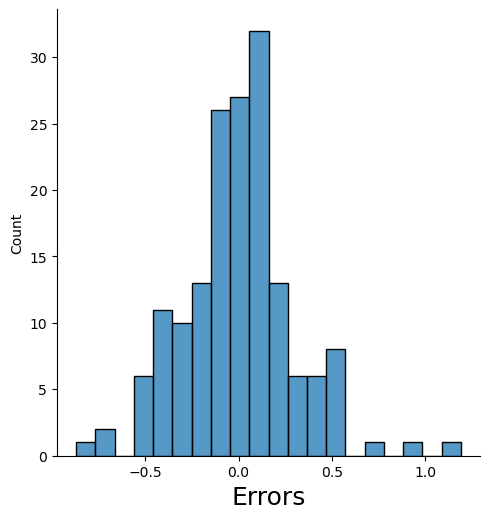

In [137]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.displot((y_train - y_train_price), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)                         # X-label

# Making Predictions
We would first need to scale the test set as well. So let's start with that.

In [138]:
df_test[varlist] = scaler.transform(df_test[varlist])

In [139]:
# Split the 'df_test' set into X and y
y_test = df_test.pop('price')
X_test = df_test

In [140]:
# Let's check the list 'col2' which had the 10 variables RFE had selected
col2

Index(['curbweight', 'enginesize', 'enginelocation_rear', 'enginetype_rotor',
       'fuelsystem_mfi', 'car_company_bmw', 'car_company_buick',
       'car_company_peugeot', 'car_company_porsche', 'car_company_renault'],
      dtype='object')

In [141]:
X_test_rfe2 = X_test[col2].drop(['fuelsystem_mfi'], axis = 1)

In [142]:
# Add a constant to the test set created
X_test_rfe2 = sm.add_constant(X_test_rfe2)
X_test_rfe2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 160 to 74
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   const                41 non-null     float64
 1   curbweight           41 non-null     float64
 2   enginesize           41 non-null     float64
 3   enginelocation_rear  41 non-null     bool   
 4   enginetype_rotor     41 non-null     bool   
 5   car_company_bmw      41 non-null     bool   
 6   car_company_buick    41 non-null     bool   
 7   car_company_peugeot  41 non-null     bool   
 8   car_company_porsche  41 non-null     bool   
 9   car_company_renault  41 non-null     bool   
dtypes: bool(7), float64(3)
memory usage: 1.6 KB


In [144]:
# Making predictions
y_pred = model2.predict(X_test_rfe2)

Text(0, 0.5, 'y_pred')

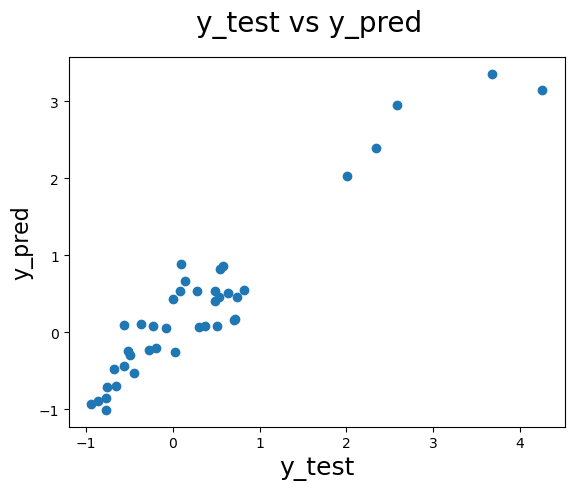

In [145]:
# Plotting y_test and y_pred to understand the spread

fig = plt.figure()
plt.scatter(y_test, y_pred)
fig.suptitle('y_test vs y_pred', fontsize = 20)              # Plot heading 
plt.xlabel('y_test', fontsize = 18)                          # X-label
plt.ylabel('y_pred', fontsize = 16)  

In [146]:
# r2_score 
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9040196938126634